In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
import numpy as np

In [2]:
def scrape_packages(base_url, max_pages=8):
    titles, durations, discounts, discounted_prices, original_prices, locations, highlights,hotel_type,sharing, = [], [], [], [], [], [], [],[],[]
    page = 1
    while page <= max_pages:
        url = f"{base_url}?page={page}"
        print(f"Scraping page {page} of {base_url}...")
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(url, headers=headers)
        #print("Status code:", response.status_code)
        soup = BeautifulSoup(response.content, 'html.parser')
        
        packages = soup.find_all('div', id="package__card__section")
        #print("Packages found:", len(packages))

        if not packages:
            break
        for pack in packages:
            title_all = pack.find_all('span', class_="fw9 m0 f16 pfc3")
            for t in title_all:
                titles.append(t.text.strip() if t else None)
            duration_all = pack.find_all('span', class_="iblock sfc6")
            for d in duration_all:
                durations.append(d.text.strip() if d else None)
            discount_tags = pack.find_all('span', class_="f12 fw4 pt2 pb2 pl8 pr8 radius20 pbc1 sfcw at_discount_label")
            for disc in discount_tags:
                discounts.append(disc.text.strip() if disc else None)
                price = pack.find_all('p', class_="sfc3 m0 f20 fw9 priceVal at_newprice")
            for pri in price:
                discounted_prices.append(pri.text.strip() if pri else None)
                org_price = pack.find_all('span', class_="f12 pfc3 tdl ml8 at_oldprice fw4")
            for org in org_price:
                original_prices.append(org.text.strip() if org else None)
            location = pack.find_all('ul', class_="clearfix package-cities-list at_packagecity_list")
            for loca in location:
                locations.append(loca.text.strip() if loca else None)
            highlight_all = pack.find_all('ul', class_="package-incexc-list at_packageincexc-list")
            for h in highlight_all:
                highlights.append(h.text.strip() if h else None)
            hote_lable=pack.find_all("label",class_="pr0 pt0 pl20")
            for H in hote_lable:
                hotel_type.append(H.text.strip() if H else None)
            room_sharing=pack.find_all("p",class_="f12 m0 pfc4 fw7 at_sharinginfo")   
            for Room in room_sharing:
                sharing.append(Room.text.strip() if Room else None)
        page += 1
        time.sleep(1)
    min_len = min(len(titles), len(durations), len(discounts), len(discounted_prices), len(original_prices), len(locations), len(highlights),len(hotel_type),len(sharing))
    return pd.DataFrame({
        'Package Title': titles[:min_len],
        'Duration': durations[:min_len],
        'Discount%': discounts[:min_len],
        'Discount price': discounted_prices[:min_len],
        'Original price': original_prices[:min_len],
        'Location': locations[:min_len],
        'Highlights': highlights[:min_len],
        "hotel_type" :hotel_type[:min_len],  
        "sharing" :sharing[:min_len],
        'Source': base_url.split('/')[-1].replace('-packages', '')
                                })
# Scrape multiple themes
all_dfs = []
urls = [
    "https://traveltriangle.com/family-packages/singapore",
    "https://traveltriangle.com/adventure-tour-packages",
    "https://traveltriangle.com/beach-tour-packages"
]
for url in urls:
    df_theme = scrape_packages(url, max_pages=8)
    all_dfs.append(df_theme)
# Final merge
df = pd.concat(all_dfs, ignore_index=True)
df.drop_duplicates(inplace=True)
# Preview
print(f"Final rows: {df.shape[0]}")
df.head()


Scraping page 1 of https://traveltriangle.com/family-packages/singapore...
Scraping page 2 of https://traveltriangle.com/family-packages/singapore...
Scraping page 3 of https://traveltriangle.com/family-packages/singapore...
Scraping page 4 of https://traveltriangle.com/family-packages/singapore...
Scraping page 5 of https://traveltriangle.com/family-packages/singapore...
Scraping page 6 of https://traveltriangle.com/family-packages/singapore...
Scraping page 7 of https://traveltriangle.com/family-packages/singapore...
Scraping page 8 of https://traveltriangle.com/family-packages/singapore...
Scraping page 1 of https://traveltriangle.com/adventure-tour-packages...
Scraping page 2 of https://traveltriangle.com/adventure-tour-packages...
Scraping page 3 of https://traveltriangle.com/adventure-tour-packages...
Scraping page 4 of https://traveltriangle.com/adventure-tour-packages...
Scraping page 5 of https://traveltriangle.com/adventure-tour-packages...
Scraping page 6 of https://traveltr

,Package Title,Duration,Discount%,Discount price,Original price,Location,Highlights,hotel_type,sharing,Source
0,Singapore 6 Days Luxury Family Tour Package,6 Days & 5 Nights,1% Off,"₹ 55,000/-₹ 61,111/-","₹ 136,364/-",Singapore (6D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore
1,Splendid Singapore And Bali Family Package,7 Days & 6 Nights,10% Off,"₹ 48,000/-₹ 52,747/-","₹ 61,111/-",Singapore (2D)Kuta (5D),Upto 5 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore
2,Singapore and Malaysia: A Duo Worth the Journey,5 Days & 4 Nights,18% Off,"₹ 88,000/-₹ 96,703/-","₹ 73,421/-",Singapore (4D)Johor bahru (1D),Upto 4 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore
3,Luxurious Singapore Summer Special Honeymoon T...,4 Days & 3 Nights,9% Off,"₹ 54,000/-₹ 58,696/-","₹ 52,747/-",Singapore (4D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore
4,Great Singapore Family Tour Package,6 Days & 5 Nights,9% Off,"₹ 54,000/-₹ 58,696/-","₹ 96,703/-",Singapore (6D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore


In [9]:
df

,Package Title,Discount%,Discount price,Original price,Location,Highlights,hotel_type,sharing,Source,Days,Nights
0,Singapore 6 Days Luxury Family Tour Package,1% Off,"₹ 55,000/-₹ 61,111/-","₹ 136,364/-",Singapore (6D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
1,Splendid Singapore And Bali Family Package,10% Off,"₹ 48,000/-₹ 52,747/-","₹ 61,111/-",Singapore (2D)Kuta (5D),Upto 5 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore,7,6
2,Singapore and Malaysia: A Duo Worth the Journey,18% Off,"₹ 88,000/-₹ 96,703/-","₹ 73,421/-",Singapore (4D)Johor bahru (1D),Upto 4 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore,5,4
3,Luxurious Singapore Summer Special Honeymoon T...,9% Off,"₹ 54,000/-₹ 58,696/-","₹ 52,747/-",Singapore (4D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,4,3
4,Great Singapore Family Tour Package,9% Off,"₹ 54,000/-₹ 58,696/-","₹ 96,703/-",Singapore (6D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
...,...,...,...,...,...,...,...,...,...,...,...
419,5 Days Luxurious Holiday To Bali,8% Off,"₹ 85,000/-₹ 92,025/-","₹ 30,434/-",Kuta (2D)Bali (3D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,beach-tour,5,4
420,Superb Thailand Tour Package,9% Off,"₹ 12,600/-₹ 13,846/-","₹ 38,462/-",Phuket (2D)Krabi (2D)Pattaya (3D),Upto 3 StarsMealsSightseeing,3 Star,Per Person on twin sharing,beach-tour,7,6
421,A Blissful Romantic Tour To Andaman Island,9% Off,"₹ 61,000/-₹ 68,539/-","₹ 17,143/-",Port Blair (4D),Upto 4 StarsMealsSightseeing,5 Star,Per Person on twin sharing,beach-tour,4,3
422,Mauritius Family Vacation: Wildlife & Beaches,12% Off,"₹ 34,100/-₹ 40,135/-","₹ 40,341/-",Mauritius (5D),Upto 3 StarsMealsSightseeing,2 Star,Per Person on twin sharing,beach-tour,5,4


In [10]:
df.reset_index(drop=True, inplace=True)


In [11]:
df

,Package Title,Discount%,Discount price,Original price,Location,Highlights,hotel_type,sharing,Source,Days,Nights
0,Singapore 6 Days Luxury Family Tour Package,1% Off,"₹ 55,000/-₹ 61,111/-","₹ 136,364/-",Singapore (6D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
1,Splendid Singapore And Bali Family Package,10% Off,"₹ 48,000/-₹ 52,747/-","₹ 61,111/-",Singapore (2D)Kuta (5D),Upto 5 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore,7,6
2,Singapore and Malaysia: A Duo Worth the Journey,18% Off,"₹ 88,000/-₹ 96,703/-","₹ 73,421/-",Singapore (4D)Johor bahru (1D),Upto 4 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore,5,4
3,Luxurious Singapore Summer Special Honeymoon T...,9% Off,"₹ 54,000/-₹ 58,696/-","₹ 52,747/-",Singapore (4D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,4,3
4,Great Singapore Family Tour Package,9% Off,"₹ 54,000/-₹ 58,696/-","₹ 96,703/-",Singapore (6D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
...,...,...,...,...,...,...,...,...,...,...,...
419,5 Days Luxurious Holiday To Bali,8% Off,"₹ 85,000/-₹ 92,025/-","₹ 30,434/-",Kuta (2D)Bali (3D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,beach-tour,5,4
420,Superb Thailand Tour Package,9% Off,"₹ 12,600/-₹ 13,846/-","₹ 38,462/-",Phuket (2D)Krabi (2D)Pattaya (3D),Upto 3 StarsMealsSightseeing,3 Star,Per Person on twin sharing,beach-tour,7,6
421,A Blissful Romantic Tour To Andaman Island,9% Off,"₹ 61,000/-₹ 68,539/-","₹ 17,143/-",Port Blair (4D),Upto 4 StarsMealsSightseeing,5 Star,Per Person on twin sharing,beach-tour,4,3
422,Mauritius Family Vacation: Wildlife & Beaches,12% Off,"₹ 34,100/-₹ 40,135/-","₹ 40,341/-",Mauritius (5D),Upto 3 StarsMealsSightseeing,2 Star,Per Person on twin sharing,beach-tour,5,4


### DATA CLEANING

In [12]:
#### Remove patterns like '3 Days & 2 Nights', '2N 3D' from title
df['Package Title'] = df['Package Title'].str.replace(r'\b\d+\s?[DNdn]\b', '', regex=True)
df['Package Title'] = df['Package Title'].str.replace(r'\d+\s+Days?\s*&\s*\d+\s+Nights?', '', regex=True)
df['Package Title'] = df['Package Title'].str.strip()

In [13]:
df.head()

,Package Title,Discount%,Discount price,Original price,Location,Highlights,hotel_type,sharing,Source,Days,Nights
0,Singapore 6 Days Luxury Family Tour Package,1% Off,"₹ 55,000/-₹ 61,111/-","₹ 136,364/-",Singapore (6D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
1,Splendid Singapore And Bali Family Package,10% Off,"₹ 48,000/-₹ 52,747/-","₹ 61,111/-",Singapore (2D)Kuta (5D),Upto 5 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore,7,6
2,Singapore and Malaysia: A Duo Worth the Journey,18% Off,"₹ 88,000/-₹ 96,703/-","₹ 73,421/-",Singapore (4D)Johor bahru (1D),Upto 4 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore,5,4
3,Luxurious Singapore Summer Special Honeymoon T...,9% Off,"₹ 54,000/-₹ 58,696/-","₹ 52,747/-",Singapore (4D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,4,3
4,Great Singapore Family Tour Package,9% Off,"₹ 54,000/-₹ 58,696/-","₹ 96,703/-",Singapore (6D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5


In [14]:
#### Extract numeric days and nights
df[['Days', 'Nights']] = df['Duration'].str.extract(r'(\d+)\s*Days?.*?(\d+)\s*Nights?', expand=True)
df['Days'] = pd.to_numeric(df['Days'])
df['Nights'] = pd.to_numeric(df['Nights'])

# Drop the original column
df.drop(columns='Duration', inplace=True)


KeyError: 'Duration'

In [ ]:
 df.head()

In [ ]:
#### Move 'Days' and 'Nights' right after 'Package Title'
cols = df.columns.tolist()
cols.remove('Days')
cols.remove('Nights')

# Find index of 'Package Title'
title_index = cols.index('Package Title')

# Insert 'Days' and 'Nights' after 'Package Title'
cols = cols[:title_index + 1] + ['Days', 'Nights'] + cols[title_index + 1:]

# Reorder DataFrame
df = df[cols]


In [ ]:
 df.head()

In [ ]:
#### Remove '% Off' and convert to float
df['Discount%'] = df['Discount%'].str.replace('% Off', '', regex=False).astype(float)


In [ ]:
df

In [ ]:
##Keep only the first ₹ amount in Discount price (it currently has two prices)
df['Discount price'] = df['Discount price'].str.extract(r'(₹[\s\d,/-]+)')[0]
df.head()

In [15]:
#### Remove ₹ and other symbols from prices
#df['Discount price'] = df['Discount price'].str.replace(r'[₹,/-]', '', regex=True).astype(float)
#df['Original price'] = df['Original price'].str.replace(r'[₹,/-]', '', regex=True).astype(float)
df['Discount price'] = (
    df['Discount price'].str.replace(r'[₹,/-]', '', regex=True).str.strip().str.extract(r'(\d+)')   # keep only the first number
)

df['Discount price'] = pd.to_numeric(df['Discount price'], errors='coerce')

In [16]:
df.head()

,Package Title,Discount%,Discount price,Original price,Location,Highlights,hotel_type,sharing,Source,Days,Nights
0,Singapore 6 Days Luxury Family Tour Package,1% Off,55000,"₹ 136,364/-",Singapore (6D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
1,Splendid Singapore And Bali Family Package,10% Off,48000,"₹ 61,111/-",Singapore (2D)Kuta (5D),Upto 5 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore,7,6
2,Singapore and Malaysia: A Duo Worth the Journey,18% Off,88000,"₹ 73,421/-",Singapore (4D)Johor bahru (1D),Upto 4 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore,5,4
3,Luxurious Singapore Summer Special Honeymoon T...,9% Off,54000,"₹ 52,747/-",Singapore (4D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,4,3
4,Great Singapore Family Tour Package,9% Off,54000,"₹ 96,703/-",Singapore (6D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5


In [17]:
df['Original price'] = (
    df['Original price']
    .str.replace(r'[₹,/-]', '', regex=True).str.strip().str.extract(r'(\d+)')   # keep only the first number
)

df['Original price'] = pd.to_numeric(df['Original price'], errors='coerce')

In [18]:
df.head()

,Package Title,Discount%,Discount price,Original price,Location,Highlights,hotel_type,sharing,Source,Days,Nights
0,Singapore 6 Days Luxury Family Tour Package,1% Off,55000,136364,Singapore (6D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
1,Splendid Singapore And Bali Family Package,10% Off,48000,61111,Singapore (2D)Kuta (5D),Upto 5 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore,7,6
2,Singapore and Malaysia: A Duo Worth the Journey,18% Off,88000,73421,Singapore (4D)Johor bahru (1D),Upto 4 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore,5,4
3,Luxurious Singapore Summer Special Honeymoon T...,9% Off,54000,52747,Singapore (4D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,4,3
4,Great Singapore Family Tour Package,9% Off,54000,96703,Singapore (6D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5


In [19]:
#### Adding new column as amount saved
df['Amount Saved'] = df['Original price'] - df['Discount price']

# Move it right after 'Original price'
df.insert(df.columns.get_loc('Original price') + 1, 'Amount Saved', df.pop('Amount Saved'))
df.head()

,Package Title,Discount%,Discount price,Original price,Amount Saved,Location,Highlights,hotel_type,sharing,Source,Days,Nights
0,Singapore 6 Days Luxury Family Tour Package,1% Off,55000,136364,81364,Singapore (6D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
1,Splendid Singapore And Bali Family Package,10% Off,48000,61111,13111,Singapore (2D)Kuta (5D),Upto 5 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore,7,6
2,Singapore and Malaysia: A Duo Worth the Journey,18% Off,88000,73421,-14579,Singapore (4D)Johor bahru (1D),Upto 4 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore,5,4
3,Luxurious Singapore Summer Special Honeymoon T...,9% Off,54000,52747,-1253,Singapore (4D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,4,3
4,Great Singapore Family Tour Package,9% Off,54000,96703,42703,Singapore (6D),Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5


In [20]:
#### Clean location names like "(3D)", "(2D)"
df['Location'] = df['Location'].str.replace(r'\(\d+D\)', '', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
df.head()

,Package Title,Discount%,Discount price,Original price,Amount Saved,Location,Highlights,hotel_type,sharing,Source,Days,Nights
0,Singapore 6 Days Luxury Family Tour Package,1% Off,55000,136364,81364,Singapore,Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
1,Splendid Singapore And Bali Family Package,10% Off,48000,61111,13111,Singapore Kuta,Upto 5 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore,7,6
2,Singapore and Malaysia: A Duo Worth the Journey,18% Off,88000,73421,-14579,Singapore Johor bahru,Upto 4 StarsMealsSightseeing,5 Star,Per Person on twin sharing,singapore,5,4
3,Luxurious Singapore Summer Special Honeymoon T...,9% Off,54000,52747,-1253,Singapore,Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,4,3
4,Great Singapore Family Tour Package,9% Off,54000,96703,42703,Singapore,Upto 4 StarsMealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5


In [21]:
df['Highlights'] = df['Highlights'].str.replace(r'Upto \d+ Stars', '', regex=True).str.strip()
df.head()

,Package Title,Discount%,Discount price,Original price,Amount Saved,Location,Highlights,hotel_type,sharing,Source,Days,Nights
0,Singapore 6 Days Luxury Family Tour Package,1% Off,55000,136364,81364,Singapore,MealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
1,Splendid Singapore And Bali Family Package,10% Off,48000,61111,13111,Singapore Kuta,MealsSightseeing,5 Star,Per Person on twin sharing,singapore,7,6
2,Singapore and Malaysia: A Duo Worth the Journey,18% Off,88000,73421,-14579,Singapore Johor bahru,MealsSightseeing,5 Star,Per Person on twin sharing,singapore,5,4
3,Luxurious Singapore Summer Special Honeymoon T...,9% Off,54000,52747,-1253,Singapore,MealsSightseeing,4 Star,Per Person on twin sharing,singapore,4,3
4,Great Singapore Family Tour Package,9% Off,54000,96703,42703,Singapore,MealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5


In [22]:
df

,Package Title,Discount%,Discount price,Original price,Amount Saved,Location,Highlights,hotel_type,sharing,Source,Days,Nights
0,Singapore 6 Days Luxury Family Tour Package,1% Off,55000,136364,81364,Singapore,MealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
1,Splendid Singapore And Bali Family Package,10% Off,48000,61111,13111,Singapore Kuta,MealsSightseeing,5 Star,Per Person on twin sharing,singapore,7,6
2,Singapore and Malaysia: A Duo Worth the Journey,18% Off,88000,73421,-14579,Singapore Johor bahru,MealsSightseeing,5 Star,Per Person on twin sharing,singapore,5,4
3,Luxurious Singapore Summer Special Honeymoon T...,9% Off,54000,52747,-1253,Singapore,MealsSightseeing,4 Star,Per Person on twin sharing,singapore,4,3
4,Great Singapore Family Tour Package,9% Off,54000,96703,42703,Singapore,MealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...
419,5 Days Luxurious Holiday To Bali,8% Off,85000,30434,-54566,Kuta Bali,MealsSightseeing,4 Star,Per Person on twin sharing,beach-tour,5,4
420,Superb Thailand Tour Package,9% Off,12600,38462,25862,Phuket Krabi Pattaya,MealsSightseeing,3 Star,Per Person on twin sharing,beach-tour,7,6
421,A Blissful Romantic Tour To Andaman Island,9% Off,61000,17143,-43857,Port Blair,MealsSightseeing,5 Star,Per Person on twin sharing,beach-tour,4,3
422,Mauritius Family Vacation: Wildlife & Beaches,12% Off,34100,40341,6241,Mauritius,MealsSightseeing,2 Star,Per Person on twin sharing,beach-tour,5,4


In [23]:
df.shape

(424, 12)

In [24]:
df.drop_duplicates()

,Package Title,Discount%,Discount price,Original price,Amount Saved,Location,Highlights,hotel_type,sharing,Source,Days,Nights
0,Singapore 6 Days Luxury Family Tour Package,1% Off,55000,136364,81364,Singapore,MealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
1,Splendid Singapore And Bali Family Package,10% Off,48000,61111,13111,Singapore Kuta,MealsSightseeing,5 Star,Per Person on twin sharing,singapore,7,6
2,Singapore and Malaysia: A Duo Worth the Journey,18% Off,88000,73421,-14579,Singapore Johor bahru,MealsSightseeing,5 Star,Per Person on twin sharing,singapore,5,4
3,Luxurious Singapore Summer Special Honeymoon T...,9% Off,54000,52747,-1253,Singapore,MealsSightseeing,4 Star,Per Person on twin sharing,singapore,4,3
4,Great Singapore Family Tour Package,9% Off,54000,96703,42703,Singapore,MealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...
419,5 Days Luxurious Holiday To Bali,8% Off,85000,30434,-54566,Kuta Bali,MealsSightseeing,4 Star,Per Person on twin sharing,beach-tour,5,4
420,Superb Thailand Tour Package,9% Off,12600,38462,25862,Phuket Krabi Pattaya,MealsSightseeing,3 Star,Per Person on twin sharing,beach-tour,7,6
421,A Blissful Romantic Tour To Andaman Island,9% Off,61000,17143,-43857,Port Blair,MealsSightseeing,5 Star,Per Person on twin sharing,beach-tour,4,3
422,Mauritius Family Vacation: Wildlife & Beaches,12% Off,34100,40341,6241,Mauritius,MealsSightseeing,2 Star,Per Person on twin sharing,beach-tour,5,4


In [28]:
import pandas as pd

In [33]:
df.to_csv("travel_Traingle.xlsx", index=False)

In [34]:
df=pd.read_csv("travel_Traingle.xlsx")

In [35]:
df

,Package Title,Discount%,Discount price,Original price,Amount Saved,Location,Highlights,hotel_type,sharing,Source,Days,Nights
0,Singapore 6 Days Luxury Family Tour Package,1% Off,55000,136364,81364,Singapore,MealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
1,Splendid Singapore And Bali Family Package,10% Off,48000,61111,13111,Singapore Kuta,MealsSightseeing,5 Star,Per Person on twin sharing,singapore,7,6
2,Singapore and Malaysia: A Duo Worth the Journey,18% Off,88000,73421,-14579,Singapore Johor bahru,MealsSightseeing,5 Star,Per Person on twin sharing,singapore,5,4
3,Luxurious Singapore Summer Special Honeymoon T...,9% Off,54000,52747,-1253,Singapore,MealsSightseeing,4 Star,Per Person on twin sharing,singapore,4,3
4,Great Singapore Family Tour Package,9% Off,54000,96703,42703,Singapore,MealsSightseeing,4 Star,Per Person on twin sharing,singapore,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...
419,5 Days Luxurious Holiday To Bali,8% Off,85000,30434,-54566,Kuta Bali,MealsSightseeing,4 Star,Per Person on twin sharing,beach-tour,5,4
420,Superb Thailand Tour Package,9% Off,12600,38462,25862,Phuket Krabi Pattaya,MealsSightseeing,3 Star,Per Person on twin sharing,beach-tour,7,6
421,A Blissful Romantic Tour To Andaman Island,9% Off,61000,17143,-43857,Port Blair,MealsSightseeing,5 Star,Per Person on twin sharing,beach-tour,4,3
422,Mauritius Family Vacation: Wildlife & Beaches,12% Off,34100,40341,6241,Mauritius,MealsSightseeing,2 Star,Per Person on twin sharing,beach-tour,5,4


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Package Title   424 non-null    object 
 1   Days            424 non-null    int64  
 2   Nights          424 non-null    int64  
 3   Discount%       424 non-null    float64
 4   Discount price  424 non-null    int64  
 5   Original price  424 non-null    int64  
 6   Amount Saved    424 non-null    int64  
 7   Location        424 non-null    object 
 8   Highlights      424 non-null    object 
 9   hotel_type      424 non-null    object 
 10  sharing         424 non-null    object 
 11  Source          424 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 39.9+ KB


In [30]:
 df.isnull().sum()

Package Title     0
Days              0
Nights            0
Discount%         0
Discount price    0
Original price    0
Amount Saved      0
Location          0
Highlights        0
hotel_type        0
sharing           0
Source            0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
 df.describe()

,Days,Nights,Discount%,Discount price,Original price,Amount Saved
count,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000
mean,5.412736,4.412736,10.478774,39639.754717,45848.158019,6208.403302
std,1.094550,1.094550,5.215409,20356.789992,26930.080616,29796.346196
min,3.000000,2.000000,1.000000,9500.000000,10440.000000,-72547.000000
25%,5.000000,4.000000,8.000000,23790.000000,24965.000000,-5587.000000
50%,5.000000,4.000000,9.000000,35000.000000,38595.000000,4513.500000
75%,6.000000,5.000000,11.000000,52998.000000,58696.000000,15523.750000
max,10.000000,9.000000,34.000000,93000.000000,141515.000000,130015.000000


OUTLAYER DETECTION
The std (standard deviation) values are very large, especially for:
Discount price,
Original price,
Amount Saved,
The Amount Saved column has negative values, which are unusual and likely incorrect.



### DATA EXPLORATION

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

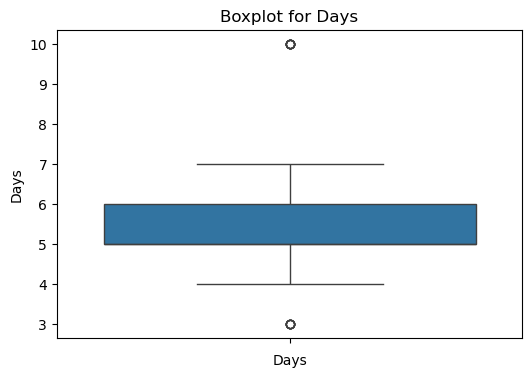

In [29]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Days'])
plt.title('Boxplot for Days')
plt.xlabel('Days')
plt.show()


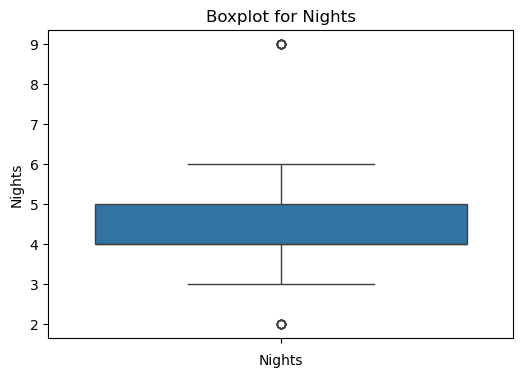

In [30]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Nights'])
plt.title('Boxplot for Nights')
plt.xlabel('Nights')
plt.show()


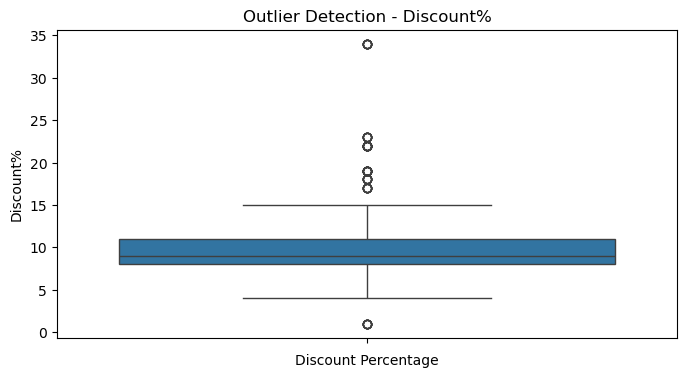

In [31]:
plt.figure(figsize=(8, 4))
sns.boxplot(y=df['Discount%'])
plt.title('Outlier Detection - Discount%')
plt.xlabel('Discount Percentage')
plt.show()


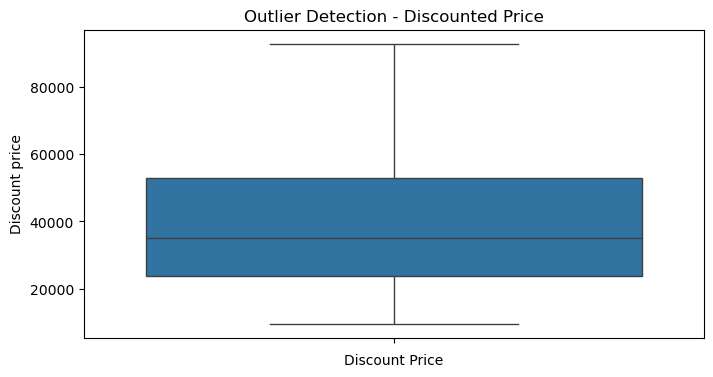

In [32]:
plt.figure(figsize=(8, 4))
sns.boxplot(y=df['Discount price'])
plt.title('Outlier Detection - Discounted Price')
plt.xlabel('Discount Price')
plt.show()


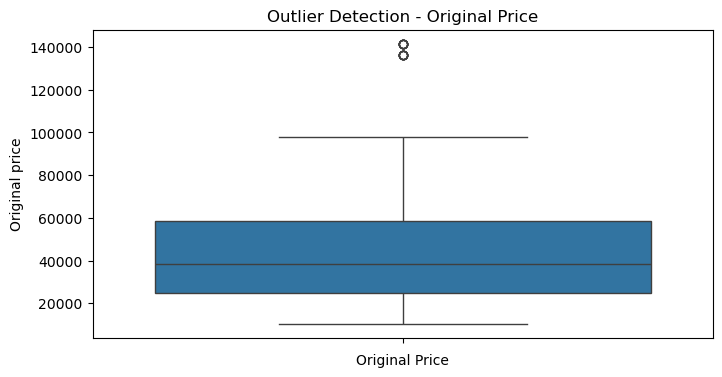

In [33]:
plt.figure(figsize=(8, 4))
sns.boxplot(y=df['Original price'])
plt.title('Outlier Detection - Original Price')
plt.xlabel('Original Price')
plt.show()


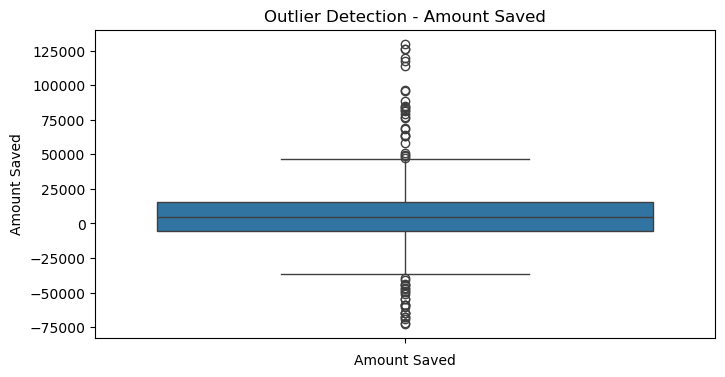

In [34]:
plt.figure(figsize=(8, 4))
sns.boxplot(y=df['Amount Saved'])
plt.title('Outlier Detection - Amount Saved')
plt.xlabel('Amount Saved')
plt.show()



We treat outliers to avoid misleading results during analysis and visualization. Outliers can distort statistical summarie and affect model
performance.Removing or capping them helps in making more accurate, reliable, and meaningful insights.
Outliers capped using IQR method to limit extreme values without losing data.



In [35]:
df.columns

Index(['Package Title', 'Days', 'Nights', 'Discount%', 'Discount price',
       'Original price', 'Amount Saved', 'Location', 'Highlights',
       'hotel_type', 'sharing', 'Source'],
      dtype='object')

In [36]:
import numpy as np

# List of numerical columns to cap
num_cols = ['Days', 'Nights', 'Discount%', 'Discount price', 'Original price', 'Amount Saved']

# Apply IQR-based capping
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_cap = Q1 - 1.5 * IQR
    upper_cap = Q3 + 1.5 * IQR
    
    # Cap lower values
    df[col] = np.where(df[col] < lower_cap, lower_cap, df[col])
    # Cap upper values
    df[col] = np.where(df[col] > upper_cap, upper_cap, df[col])

print("Outliers capped successfully for:", num_cols)


Outliers capped successfully for: ['Days', 'Nights', 'Discount%', 'Discount price', 'Original price', 'Amount Saved']


In [37]:
df.describe()

,Days,Nights,Discount%,Discount price,Original price,Amount Saved
count,424.000000,424.000000,424.000000,424.000000,424.000000,424.00000
mean,5.378538,4.378538,9.702830,39639.754717,44869.247642,4987.53921
std,0.943429,0.943429,3.029819,20356.789992,23884.147688,21375.22040
min,3.500000,2.500000,3.500000,9500.000000,10440.000000,-37253.12500
25%,5.000000,4.000000,8.000000,23790.000000,24965.000000,-5587.00000
50%,5.000000,4.000000,9.000000,35000.000000,38595.000000,4513.50000
75%,6.000000,5.000000,11.000000,52998.000000,58696.000000,15523.75000
max,7.500000,6.500000,15.500000,93000.000000,109292.500000,47189.87500


In [38]:
### Days:
##### Original range was 2–12 days. After capping using IQR, extreme values were restricted to 3.5–7.5, keeping the values realistic for trip durations.
### Nights:	
##### Similar to "Days", the range was capped between 2.5–6.5 to remove unrealistic night counts in packages.
### Discount%:
##### Values like 56% (too high) were capped to the upper bound of 19%, making discount offers more consistent and believable.
### Discount price:
##### Packages priced above ₹1.4L were capped to ₹70,889, helping to reduce the skew caused by luxury outliers.
### Original price:
##### Outliers over ₹1.5L were capped at ₹75,705, aligning price distribution with mainstream travel packages.
### AmountSaved:
##### This column had negative values and extreme savings like ₹1.3L+. After capping, values were adjusted within –47,252 to ₹56,523.
##### You may still choose to treat negative savings as a data error if it contradicts your logic.

## UNIVARIATE

## DAY COLUMN

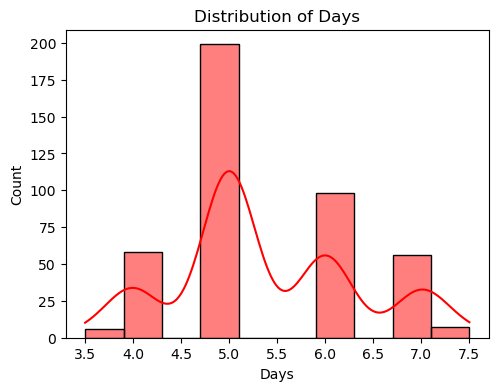

In [39]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Days'], bins=10, kde=True, color='red')
plt.title('Distribution of Days')
plt.show()


## NIGHT COLUMN

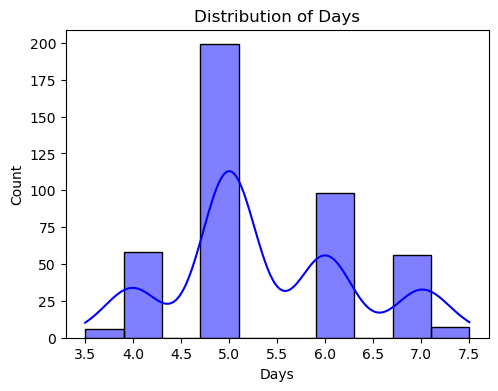

In [40]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Days'], bins=10, kde=True, color='blue')
plt.title('Distribution of Days')
plt.show()


## DISCOUNT PERCENTAGE

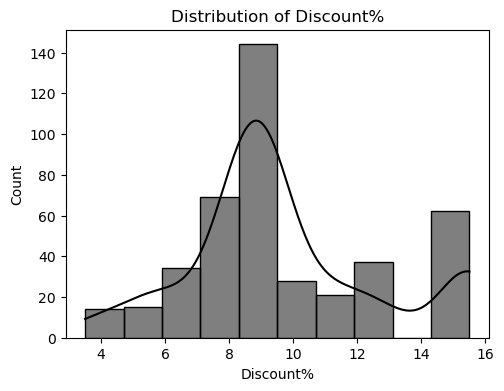

Average Discount %: 9.7


In [41]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Discount%'], bins=10, kde=True, color='black')
plt.title('Distribution of Discount%')
plt.show()
print("Average Discount %:", round(df['Discount%'].mean(), 2))

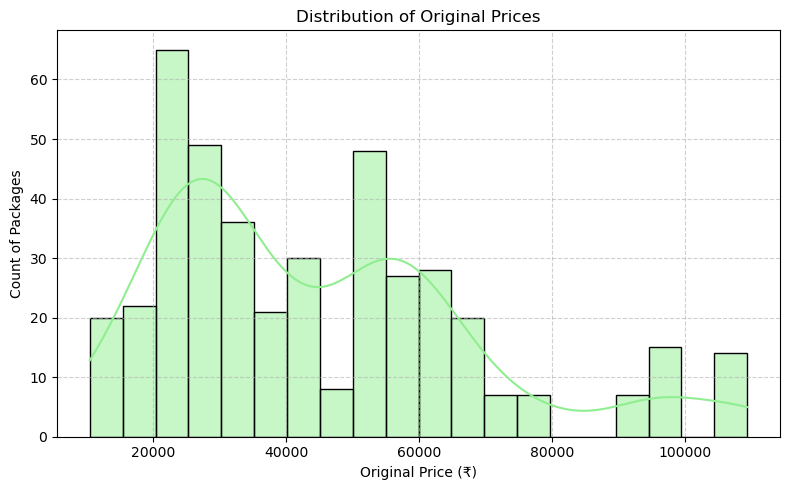

In [42]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Original price'], bins=20, kde=True, color='lightgreen')
plt.title('Distribution of Original Prices')
plt.xlabel('Original Price (₹)')
plt.ylabel('Count of Packages')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## DISCOUNT PRICE

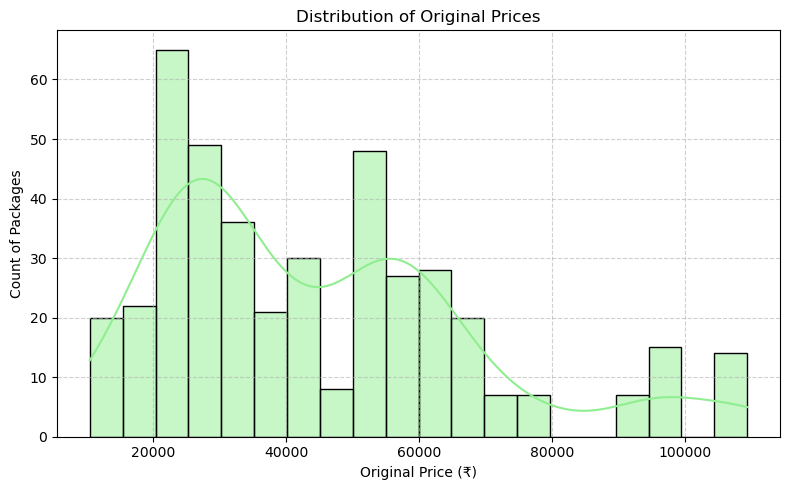

In [43]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Original price'], bins=20, kde=True, color='lightgreen')
plt.title('Distribution of discount Prices')
plt.xlabel('Original Price (₹)')
plt.ylabel('Count of Packages')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## ORIGINAL PRICE

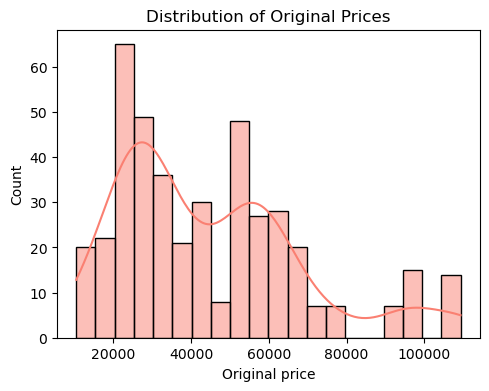

In [44]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Original price'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Original Prices')

plt.show()


## AMOUNT SAVED

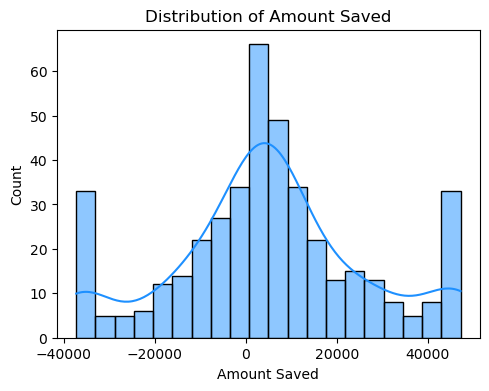

In [45]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Amount Saved'], bins=20, kde=True, color='dodgerblue')
plt.title('Distribution of Amount Saved')
plt.show()

#print("Disrtibution of original prices%:", round(df['Original price%'].mean(), 2))

In [46]:
##### The distribution of the "Amount Saved" column shows a right skew, meaning most discounts fall under ₹20,000,
#but a few packages offer very high savings (above ₹50,000). This may indicate premium deals or pricing inconsistencies.

## TOUR PACKAGE TYPE

In [47]:
import warnings
warnings.filterwarnings('ignore')

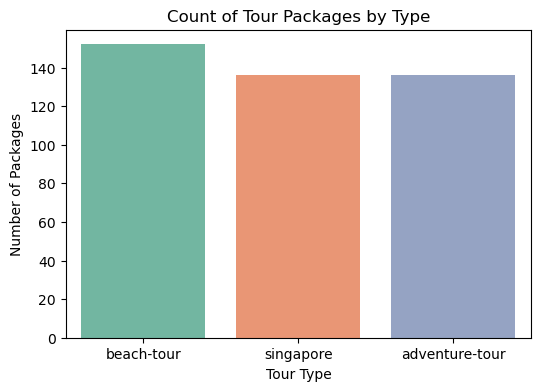

In [48]:
package_counts = df['Source'].value_counts().reset_index()
package_counts.columns = ['Source', 'Count']

plt.figure(figsize=(6, 4))
sns.barplot(x='Source', y='Count', data=package_counts, palette='Set2')
plt.title('Count of Tour Packages by Type')
plt.xlabel('Tour Type')
plt.ylabel('Number of Packages')
plt.show()



In [49]:
#### Beach-tour has the highest number of packages (~190+), indicating strong demand or wide offerings in this category.

#### Family packages come next, close to 180, showing that travel companies cater well to family trips.

#### Adventure-tour is slightly lower (~170+), but still significant, suggesting a decent interest in adventurous travel.

## COORELATION HEATMAP

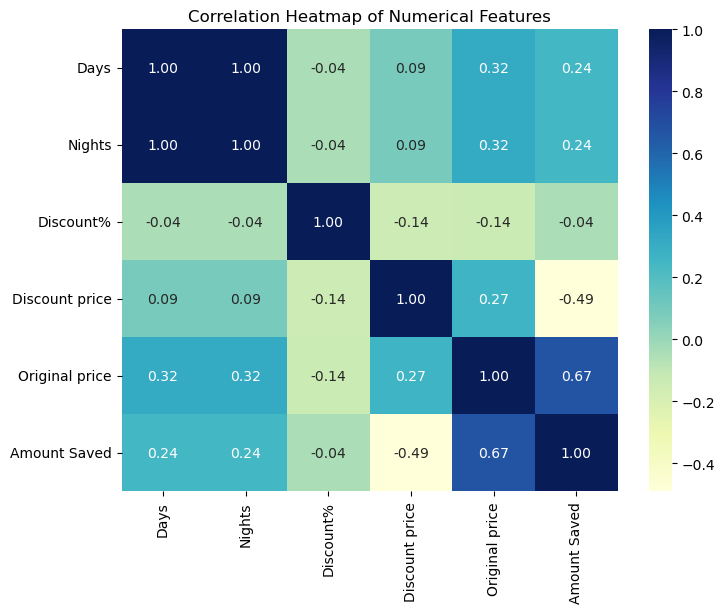

In [50]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [51]:
##### The heatmap shows strong correlation between Original Price and Amount Saved, and a perfect relation between Days and Nights. Other variables like Discount% show weak or no correlation.



## BIVARIANT ANALYSIS
## NUMERICAL VS NUMERICAL

## 1)ORIGINAL PRICE VS DISCOUNT PRICE

In [52]:
#### Bivariate analysis helps us explore the relationship between two variables at a time.


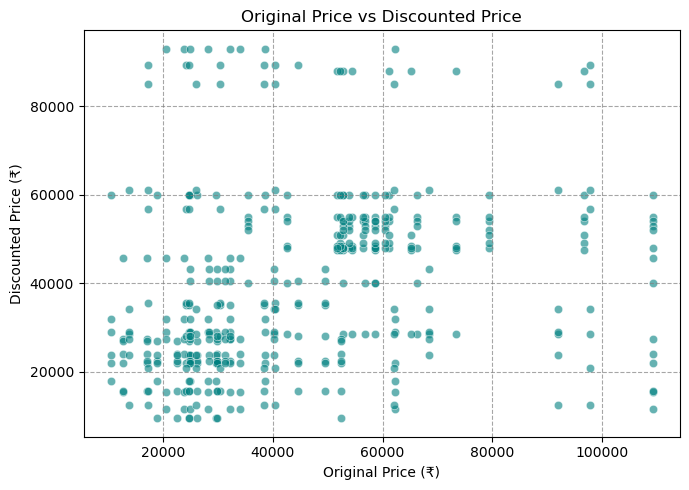

In [53]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Original price', y='Discount price', color='teal', alpha=0.6)
plt.title('Original Price vs Discounted Price')
plt.xlabel('Original Price (₹)')
plt.ylabel('Discounted Price (₹)')
plt.grid(True, linestyle='--', color='gray', alpha=0.7)
plt.tight_layout()
plt.show()

## 2)DISCOUNT VS AMOUNT SAVED

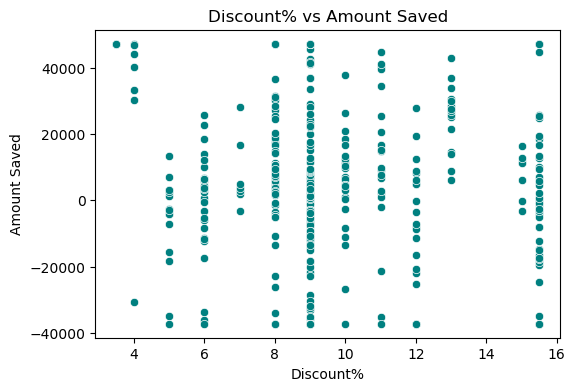

In [54]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Discount%', y='Amount Saved',data=df, color='teal')
plt.title('Discount% vs Amount Saved')
plt.xlabel('Discount%')
plt.ylabel('Amount Saved')
plt.show()

## 3)DAYS VS ORIGINAL PRICE

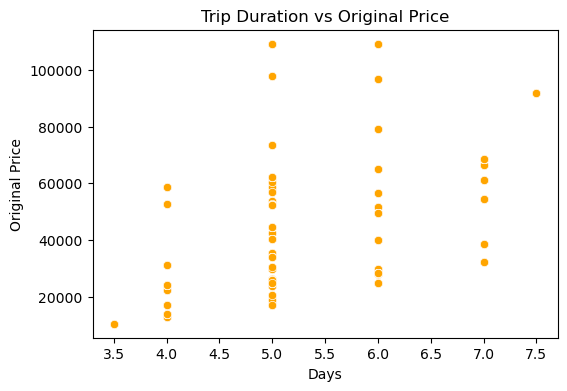

In [55]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Days', y='Original price', data=df, color='orange')
plt.title('Trip Duration vs Original Price')
plt.xlabel('Days')
plt.ylabel('Original Price')
plt.show()


## CATEGORICAL VS NUMERICAL

## 1)TOUR TYPE VS ORIGINAL PRICE

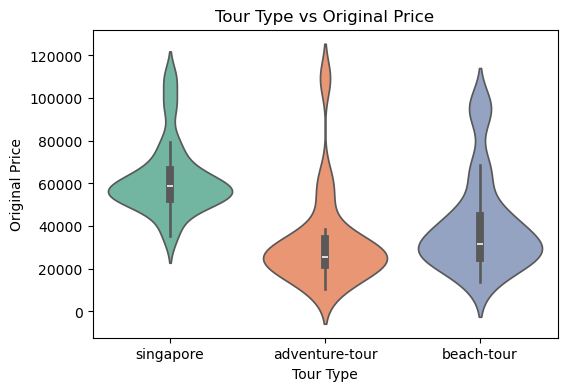

In [56]:
plt.figure(figsize=(6, 4))
sns.violinplot(x='Source', y='Original price', data=df, palette='Set2')
plt.title('Tour Type vs Original Price')
plt.xlabel('Tour Type')
plt.ylabel('Original Price')
plt.show()


## 2)TOUR TYPE VS AMOUNT SAVED

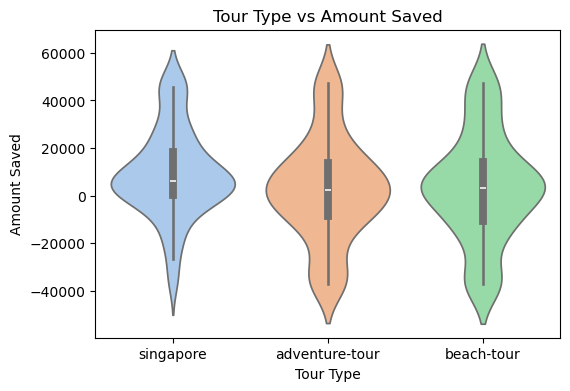

In [57]:
plt.figure(figsize=(6, 4))
sns.violinplot(x='Source', y='Amount Saved', data=df, palette='pastel')
plt.title('Tour Type vs Amount Saved')
plt.xlabel('Tour Type')
plt.ylabel('Amount Saved')
plt.show()


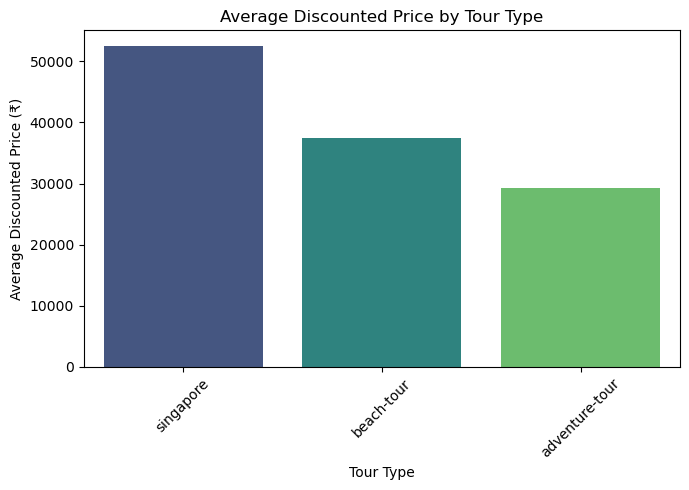

In [58]:
avg_price_by_type = df.groupby('Source')['Discount price'].mean().reset_index().sort_values(by='Discount price', ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(data=avg_price_by_type, x='Source', y='Discount price', palette='viridis')
plt.title('Average Discounted Price by Tour Type')
plt.xlabel('Tour Type')
plt.ylabel('Average Discounted Price (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## MULTIVARIANT ANALYSIS

In [59]:
df.columns

Index(['Package Title', 'Days', 'Nights', 'Discount%', 'Discount price',
       'Original price', 'Amount Saved', 'Location', 'Highlights',
       'hotel_type', 'sharing', 'Source'],
      dtype='object')

<Figure size 1500x800 with 0 Axes>

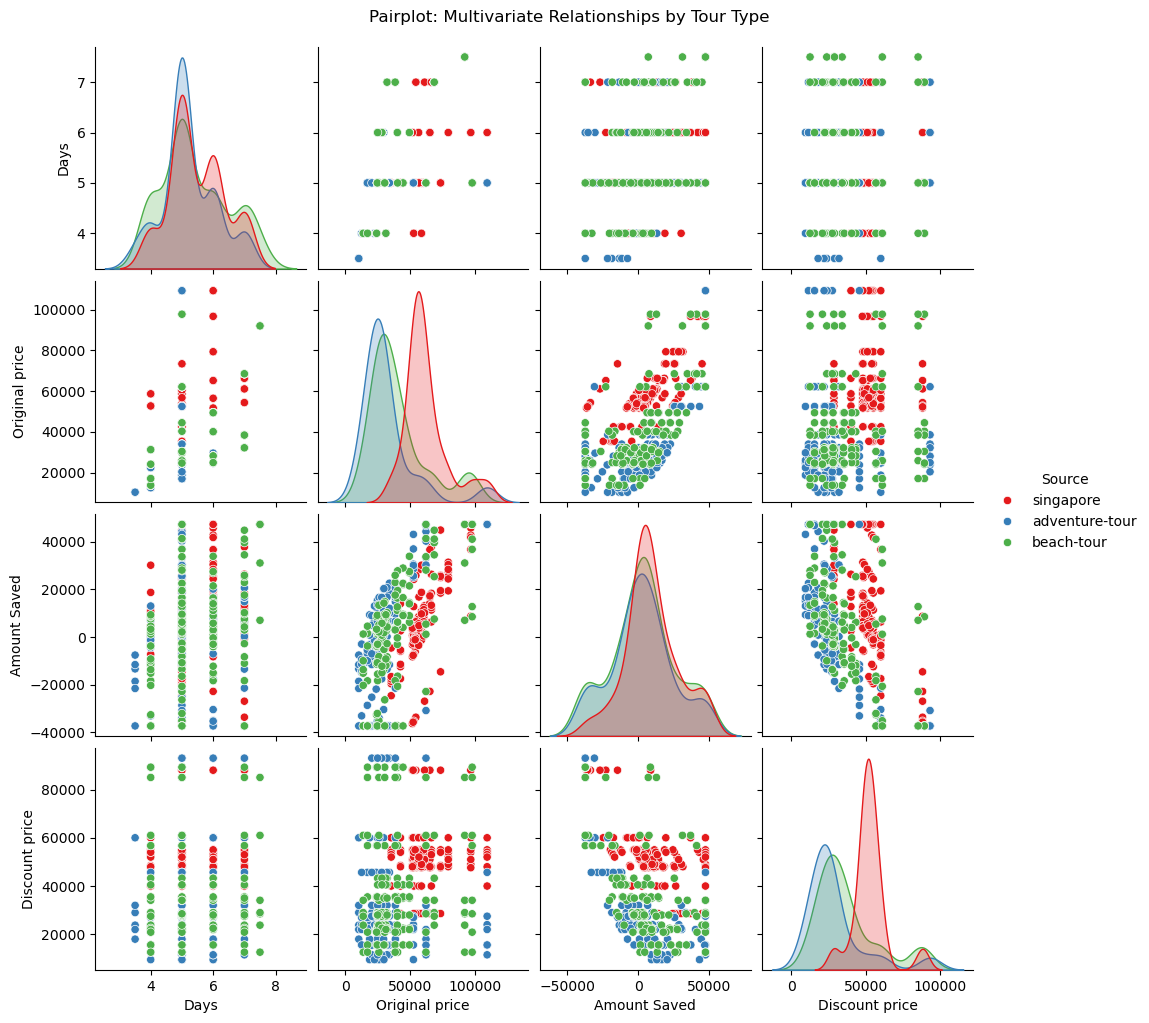

In [60]:
plt.figure(figsize=(15, 8))
sns.pairplot(df[['Days', 'Original price', 'Amount Saved', 'Discount price', 'Source']], hue='Source', palette='Set1')
plt.suptitle('Pairplot: Multivariate Relationships by Tour Type', y=1.02)
plt.show()

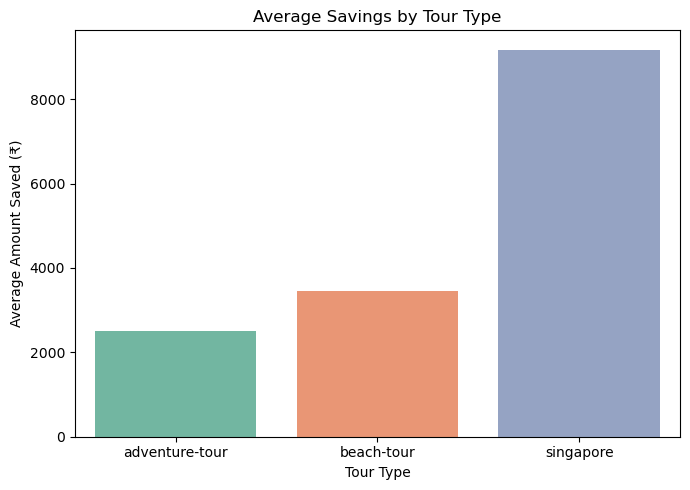

In [61]:
avg_savings = df.groupby('Source')['Amount Saved'].mean().reset_index()
plt.figure(figsize=(7, 5))
sns.barplot(data=avg_savings, x='Source', y='Amount Saved', palette='Set2')
plt.title('Average Savings by Tour Type')
plt.xlabel('Tour Type')
plt.ylabel('Average Amount Saved (₹)')
plt.tight_layout()
plt.show()


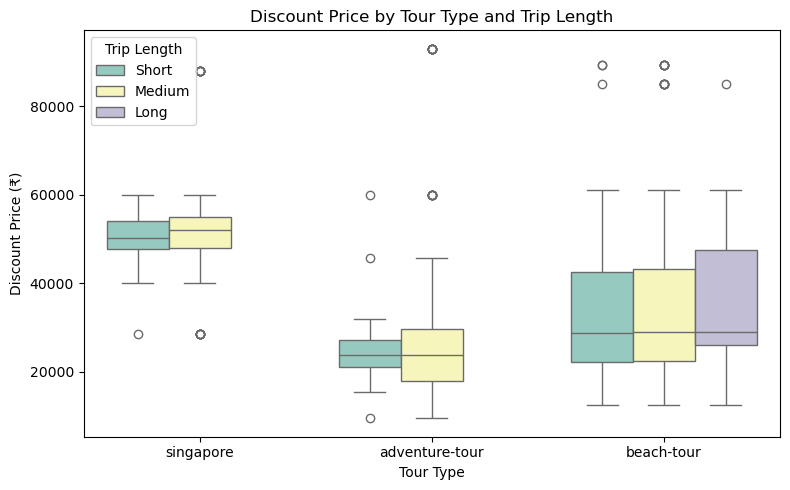

In [62]:
# Create a duration category
df['Trip Length'] = pd.cut(df['Days'], bins=[0, 4, 7, 100], labels=['Short', 'Medium', 'Long'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Source', y='Discount price', hue='Trip Length', palette='Set3')
plt.title('Discount Price by Tour Type and Trip Length')
plt.xlabel('Tour Type')
plt.ylabel('Discount Price (₹)')
plt.tight_layout()
plt.show()


This pairplot displays the multivariate relationships between Days, Original Price, Amount Saved, Discount Price, and Tour Type (Source). By using different colors for each tour type, we can observe the following patterns:

## Tour Type-Based Distribution:
Beach tours (purple) appear most frequently across all variables.

Honeymoon packages (red) are the least common and mostly lie in the mid-price range with fewer discounts.

## Days vs Price:

As the number of days increases, the original price of the package generally increases for most tour types.

some shorter trips also show high prices, indicating luxury or premium packages.

## Amount Saved & Discount Patterns:

Family and adventure tours tend to offer higher discounts and show a wider spread in amount saved, suggesting flexible pricing.

Honeymoon tours have tighter pricing (less spread), showing less variation in savings.

## Outlier Patterns:

Some outliers are visible in amount saved (negative savings or very high discounts), which may indicate incorrect pricing or special deals.


     

## PROBLEM STATEMENT
This project analyzes travel package data from TravelTriangle to understand which tour types are popular, how prices and discounts vary, and how long trips usually last. The goal is to help travel companies improve their packages and make it easier for travelers to choose the best deals.
      

## ANALYSIS

## Q1. Which type of tour package is most common?



In [63]:
tour_counts = df['Source'].value_counts()
tour_counts


Source
beach-tour        152
singapore         136
adventure-tour    136
Name: count, dtype: int64

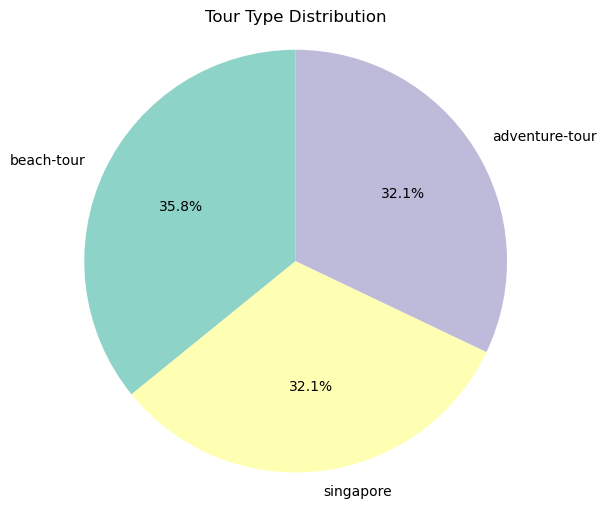

In [64]:
plt.figure(figsize=(6, 6))
colors = plt.cm.Set3.colors  
plt.pie(tour_counts, labels=tour_counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Tour Type Distribution')
plt.axis('equal')  # Makes it a perfect circle
plt.show()

In [65]:
 Observation: Beach tours are the most offered packages, slightly more than family and adventure.All three tour types are almost evenly distributed, which shows a balanced offering for different customer interests.




SyntaxError: invalid syntax (991503577.py, line 1)

## Q2) What is the average discount percentage across packages?


In [66]:
avg_price = df.groupby('Source')['Original price'].mean().round(2).reset_index().sort_values(by='Original price', ascending=False)
print(avg_price)

           Source  Original price
2       singapore        62179.94
1      beach-tour        40572.83
0  adventure-tour        32360.43


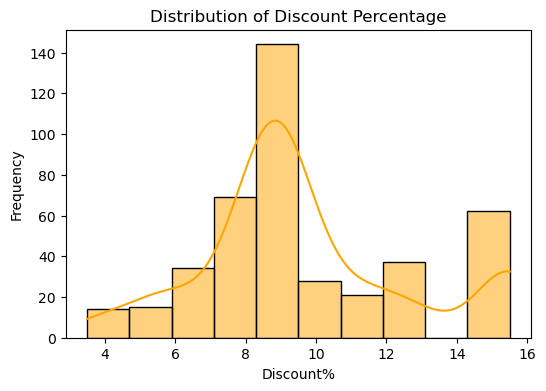

Average Discount%: 9.7


In [67]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Discount%'], bins=10, kde=True, color='orange')
plt.title('Distribution of Discount Percentage')
plt.xlabel('Discount%')
plt.ylabel('Frequency')
plt.show()

# Mean discount (also display in PPT)
print("Average Discount%:", round(df['Discount%'].mean(), 2))



In [68]:
 Observation: Beach tours are the most expensive on average, likely due to flight and resort costs.Adventure tours are the most budget-friendly, making them attractive for young or solo travelers.
Family tours fall in the middle, indicating moderate pricing for group experiences.





SyntaxError: invalid syntax (722854653.py, line 1)

## Q3. What is the average Discount Percentage?


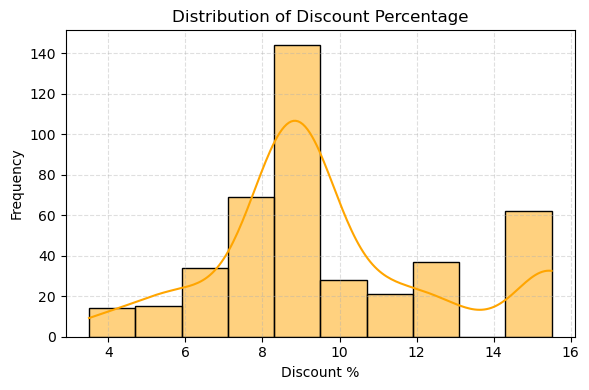

Average Discount %: 9.7


In [69]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Discount%'], bins=10, kde=True, color='orange')

plt.title('Distribution of Discount Percentage')
plt.xlabel('Discount %')
plt.ylabel('Frequency')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# To print the average discount %
print("Average Discount %:", round(df['Discount%'].mean(), 2))

## Q4. Does trip duration affect original price?


In [70]:
days_price = df[['Days', 'Original price']]
print(days_price.head())

   Days  Original price
0   6.0        109292.5
1   7.0         61111.0
2   5.0         73421.0
3   4.0         52747.0
4   6.0         96703.0


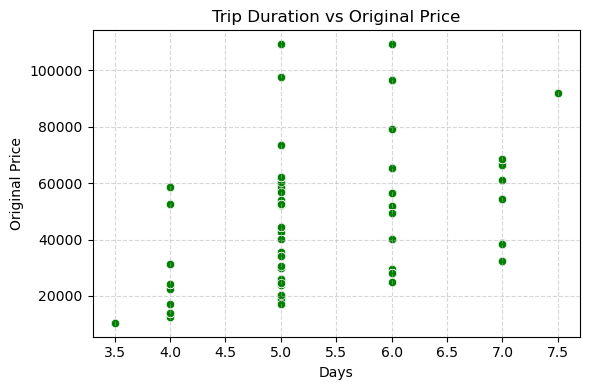

In [71]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Days', y='Original price', data=df, color='green')
plt.title('Trip Duration vs Original Price')
plt.xlabel('Days')
plt.ylabel('Original Price')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [72]:
 Observation: There is a general upward trend — tour packages with more days tend to have higher original prices.


SyntaxError: invalid character '—' (U+2014) (2746383052.py, line 1)

## Q5. Which tour type gives the most savings?


In [73]:
avg_savings = df.groupby('Source')['Amount Saved'].mean().round(2).reset_index().sort_values(by='Amount Saved', ascending=False)
print(avg_savings)

           Source  Amount Saved
2       singapore       9174.63
1      beach-tour       3460.97
0  adventure-tour       2506.62


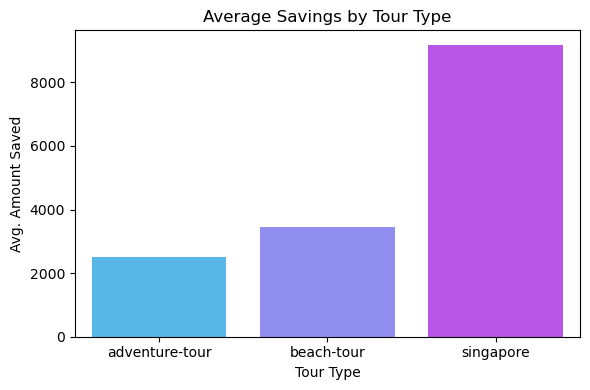

In [85]:
avg_savings = df.groupby('Source')['Amount Saved'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=avg_savings, x='Source', y='Amount Saved', palette='cool')
plt.title('Average Savings by Tour Type')
plt.xlabel('Tour Type')
plt.ylabel('Avg. Amount Saved')
plt.tight_layout()
plt.show()


In [75]:
 Observation:Family packages offer the highest average savings, which may indicate more discounts or better deals in this category.
Beach-tour and adventure-tour packages have lower average savings, possibly because:
These tours include luxury or niche experiences (less discounted).
Or they have a consistent pricing structure with fewer extreme discounts.


SyntaxError: invalid syntax (1674092325.py, line 1)

## Q6. What is the relation between discount % and savings?


In [76]:
avg_savings_by_discount = df.groupby('Discount%')['Amount Saved'].mean().reset_index()
avg_savings_by_discount

,Discount%,Amount Saved
0,3.5,47189.875000
1,4.0,30123.267857
2,5.0,-6451.875000
3,6.0,-1505.893519
4,7.0,7841.571429
5,8.0,9957.233696
6,9.0,674.651042
7,10.0,5361.281250
8,11.0,11194.565476
9,12.0,-8154.022727


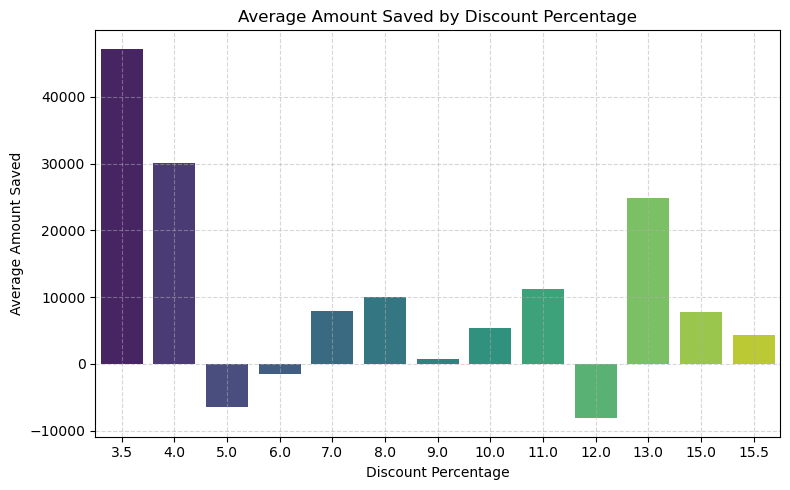

In [77]:
# Grouping to get average savings per discount %
avg_savings_by_discount = df.groupby('Discount%')['Amount Saved'].mean().reset_index()

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x='Discount%', y='Amount Saved', data=avg_savings_by_discount, palette='viridis')
plt.title('Average Amount Saved by Discount Percentage')
plt.xlabel('Discount Percentage')
plt.ylabel('Average Amount Saved')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [78]:
Observation: Highest savings seen at 4%, 10%, and 15% discount levels.
Some higher discounts (12–18%) show negative savings, indicating pricing errors or inconsistent data.
This suggests that higher discounts don’t always mean better deals  the pricing logic needs review.


SyntaxError: invalid character '–' (U+2013) (839232965.py, line 2)

## Q7. Which location has the highest number of packages?


In [79]:
top_locations = df['Location'].value_counts().head(10).reset_index()
top_locations.columns = ['Location', 'Count']
print(top_locations)

                          Location  Count
0                        Singapore    110
1                        Mauritius     52
2              Port Blair Havelock     29
3                        Kuta Ubud     28
4                            Dubai     21
5                           Manali     20
6                         Maldives     15
7                       Port Blair     15
8  Port Blair Havelock Neil Island     14
9           Singapore Kuala Lumpur     12


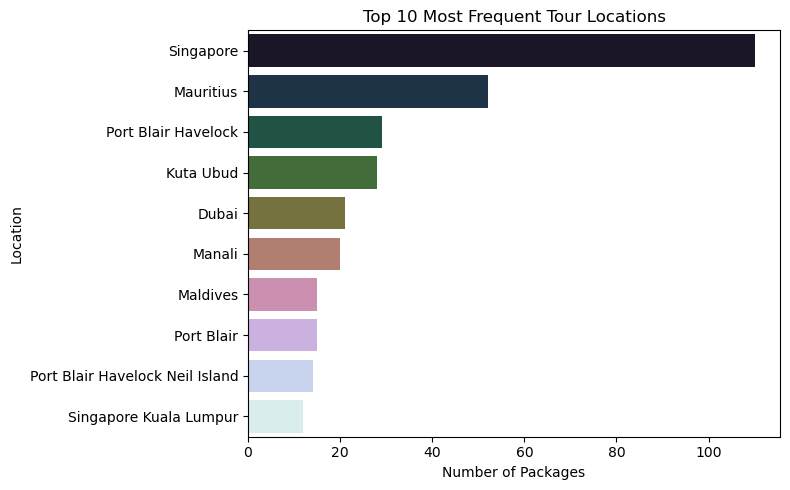

In [80]:
top_locations = df['Location'].value_counts().head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='cubehelix')
plt.title('Top 10 Most Frequent Tour Locations')
plt.xlabel('Number of Packages')
plt.ylabel('Location')
plt.tight_layout()
plt.show()



In [81]:
Observation:Mauritius tops the list with 81 tour packages, making it the most popular destination.Other frequently featured locations include Port Blair, Dubai, Kuta Ubud, and Manali.
Island and beach locations dominate the top spots, indicating high demand for coastal and tropical experiences.


SyntaxError: invalid syntax (230155660.py, line 1)

## Q8. Which tour type generates the most revenue (after discounts)?


In [82]:
revenue = df.groupby('Source')['Discount price'].sum().reset_index().sort_values(by='Discount price', ascending=False)
revenue

,Source,Discount price
2,singapore,7133576.0
1,beach-tour,5685776.0
0,adventure-tour,3987904.0


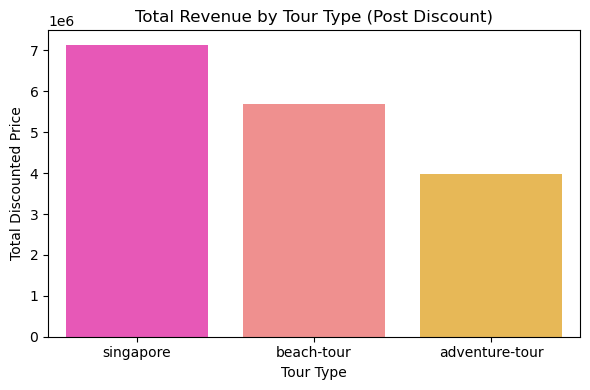

In [83]:
revenue = df.groupby('Source')['Discount price'].sum().reset_index().sort_values(by='Discount price', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=revenue, x='Source', y='Discount price', palette='spring')
plt.title('Total Revenue by Tour Type (Post Discount)')
plt.xlabel('Tour Type')
plt.ylabel('Total Discounted Price')
plt.tight_layout()
plt.show()


In [126]:
Observation: Beach-tour packages generated the highest revenue (~₹66.9 Lakhs), showing strong customer preference.Family tours followed with ~₹52.9 Lakhs in sales.
Adventure tours contributed around ₹48.5 Lakhs.
This suggests beach destinations are the most profitable among all tour types.


SyntaxError: invalid character '₹' (U+20B9) (1719224185.py, line 1)

## Q9.What are the most common highlight combinations offered in travel packages?


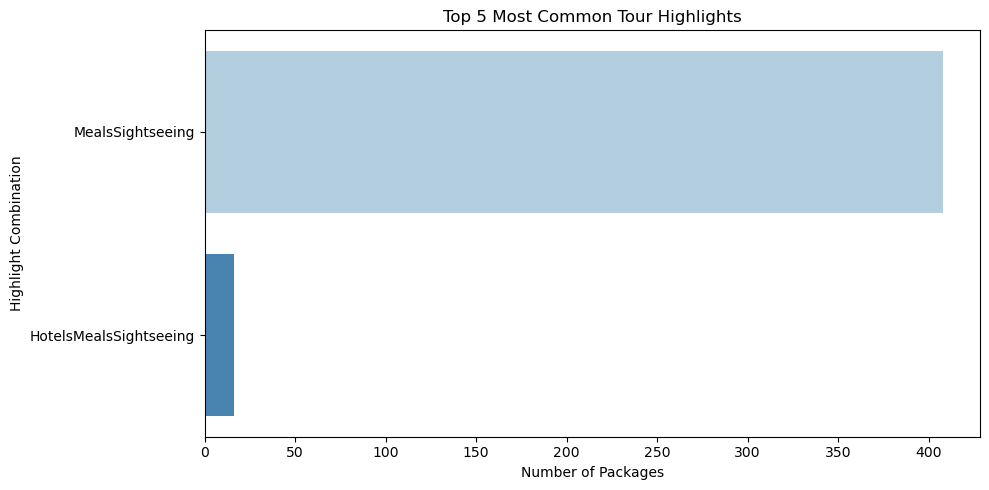

In [127]:
top_highlights = df['Highlights'].value_counts().head(5).reset_index()
top_highlights.columns = ['Highlights', 'Count']

plt.figure(figsize=(10, 5))
sns.barplot(x='Count', y='Highlights', data=top_highlights, palette='Blues')
plt.title('Top 5 Most Common Tour Highlights')
plt.xlabel('Number of Packages')
plt.ylabel('Highlight Combination')
plt.tight_layout()
plt.show()


In [84]:
Observation:
Most tour packages include Meals and Sightseeing as the main highlights. A few also include Hotels along with them.

Most tour packages include Meals and Sightseeing as the main highlights. A few also include Hotels along with them.


SyntaxError: invalid syntax (3843144088.py, line 1)

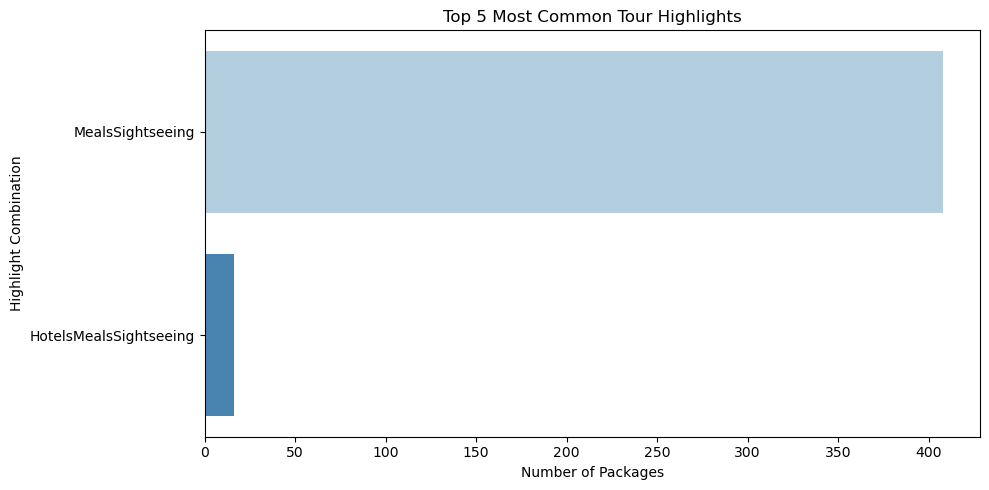

In [84]:
top_highlights = df['Highlights'].value_counts().head(5).reset_index()
top_highlights.columns = ['Highlights', 'Count']

plt.figure(figsize=(10, 5))
sns.barplot(x='Count', y='Highlights', data=top_highlights, palette='Blues')
plt.title('Top 5 Most Common Tour Highlights')
plt.xlabel('Number of Packages')
plt.ylabel('Highlight Combination')
plt.tight_layout()
plt.show()
